In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

  english_term spanish_term  migrationsbezug_eng  migrationsbezug_spa  \
0     A-Number     Número A                    1                    1   
1     A-Number     Número A                    1                    1   
2     A-Number     Número A                    1                    1   
3     A-Number     Número A                    1                    1   
4     A-Number     Número A                    1                    1   

   polysemie_eng  polysemie_spa  topic_number  \
0              0              0             3   
1              0              0             3   
2              0              0             3   
3              0              0             3   
4              0              0             3   

                                topic  migrationsbezug_equal  \
0  Dokument, Visa, formelle Nachweise                      1   
1  Dokument, Visa, formelle Nachweise                      1   
2  Dokument, Visa, formelle Nachweise                      1   
3  Dokumen

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

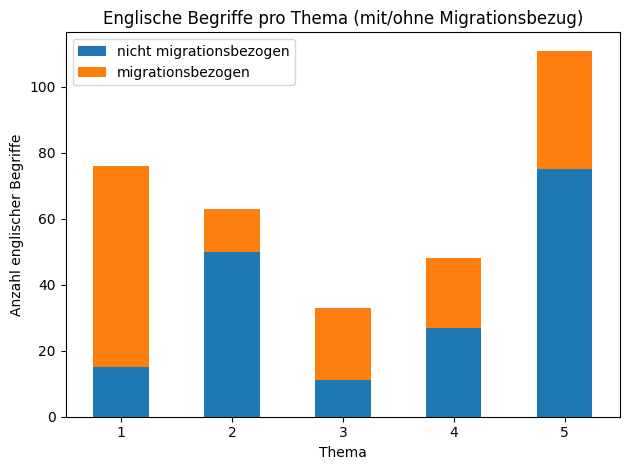

In [3]:
grouped_eng = clean_df.groupby(['topic_number', 'migrationsbezug_eng'])['english_term'].nunique().unstack(fill_value=0)
import matplotlib.pyplot as plt

grouped_eng.plot(kind='bar', stacked=True)

plt.xlabel('Thema')
plt.ylabel('Anzahl englischer Begriffe')
plt.title('Englische Begriffe pro Thema (mit/ohne Migrationsbezug)')
plt.legend(labels=['nicht migrationsbezogen', 'migrationsbezogen'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

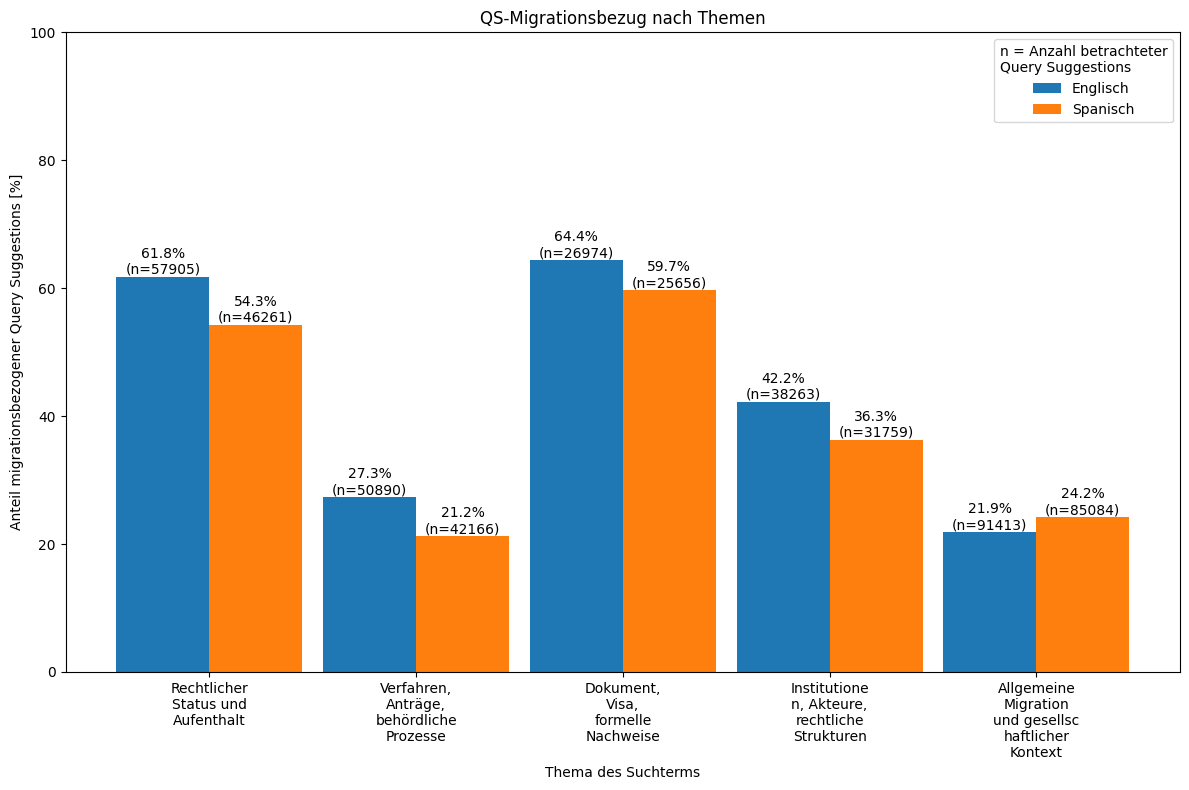

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# ------------------------------------------------------------
# Hilfsfunktion: Zeilenumbruch für lange Topics
# ------------------------------------------------------------
def wrap_text(text, width=12):
    return "\n".join(textwrap.wrap(str(text), width))

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# ------------------------------------------------------------
# ENGLISCH
# ------------------------------------------------------------
subset_eng = df[
    (df['qs_eng'].notna()) &
    (df['qs_migrationsbezug_eng_final'].notna()) &
    (df['topic'].notna()) &
    (df['topic_number'].notna())
].copy()

eng_grouped = (
    subset_eng
    .groupby(['topic_number', 'topic'])
    .agg(
        pct=('qs_migrationsbezug_eng_final', lambda x: x.mean() * 100),
        n=('qs_eng', 'count')
    )
    .reset_index()
)

# ------------------------------------------------------------
# SPANISCH
# ------------------------------------------------------------
subset_spa = df[
    (df['qs_spa'].notna()) &
    (df['qs_migrationsbezug_spa_final'].notna()) &
    (df['topic'].notna()) &
    (df['topic_number'].notna())
].copy()

spa_grouped = (
    subset_spa
    .groupby(['topic_number', 'topic'])
    .agg(
        pct=('qs_migrationsbezug_spa_final', lambda x: x.mean() * 100),
        n=('qs_spa', 'count')
    )
    .reset_index()
)

# ------------------------------------------------------------
# Merge + Sortierung nach topic_number
# ------------------------------------------------------------
merged = pd.merge(
    eng_grouped,
    spa_grouped,
    on=['topic_number', 'topic'],
    how='outer',
    suffixes=('_eng', '_spa')
).sort_values('topic_number')

# ------------------------------------------------------------
# Werte extrahieren + Topic umbrechen
# ------------------------------------------------------------
topics = merged['topic'].apply(lambda x: wrap_text(x, width=12))
x = np.arange(len(topics))

eng_values = merged['pct_eng']
spa_values = merged['pct_spa']

eng_counts = merged['n_eng']
spa_counts = merged['n_spa']

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
width = 0.45
plt.figure(figsize=(12, 8))

bars1 = plt.bar(x - width/2, eng_values, width, label='Englisch')
bars2 = plt.bar(x + width/2, spa_values, width, label='Spanisch')

plt.ylabel('Anteil migrationsbezogener Query Suggestions [%]')
plt.xlabel('Thema des Suchterms')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen')

plt.xticks(x, topics, rotation=0)
plt.legend(title="n = Anzahl betrachteter\nQuery Suggestions")

# ------------------------------------------------------------
# Labels: Prozent + n
# ------------------------------------------------------------
for i, bar in enumerate(bars1):
    height = bar.get_height()
    if pd.notna(height):
        n = eng_counts.iloc[i]
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}%\n(n={int(n)})',
            ha='center',
            va='bottom'
        )

for i, bar in enumerate(bars2):
    height = bar.get_height()
    if pd.notna(height):
        n = spa_counts.iloc[i]
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}%\n(n={int(n)})',
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

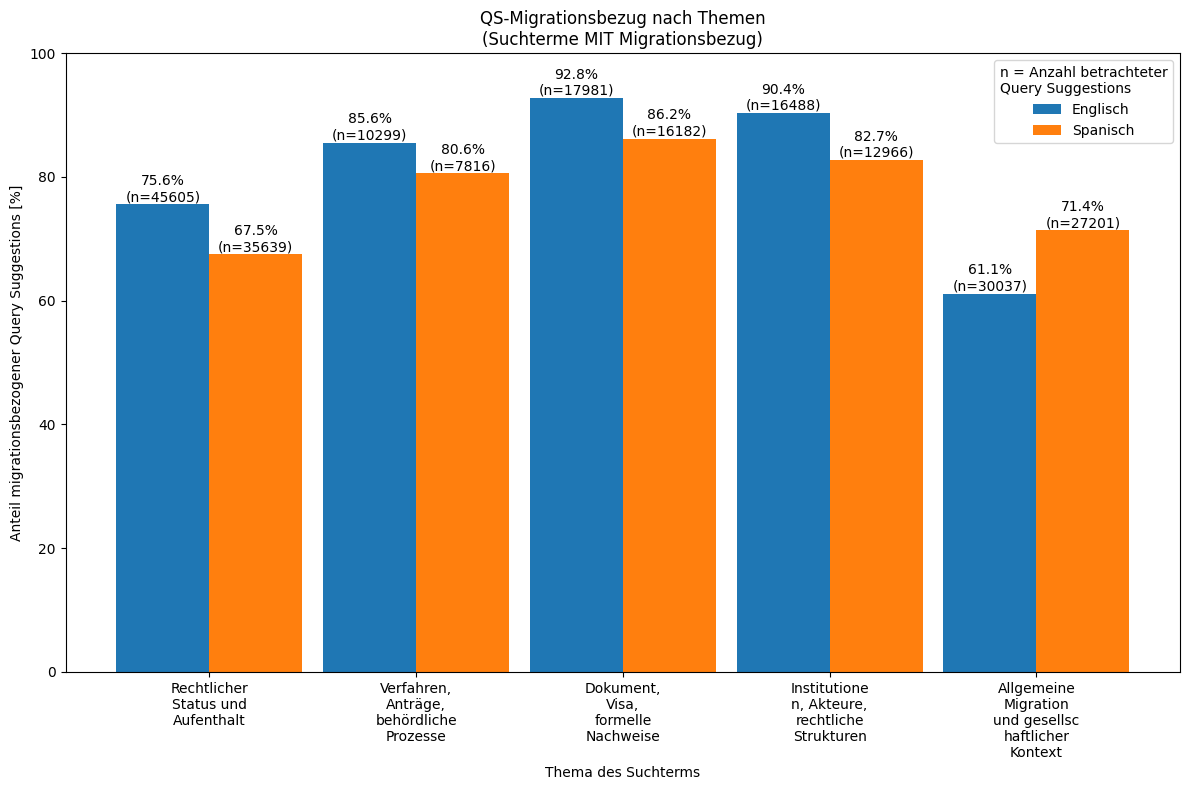

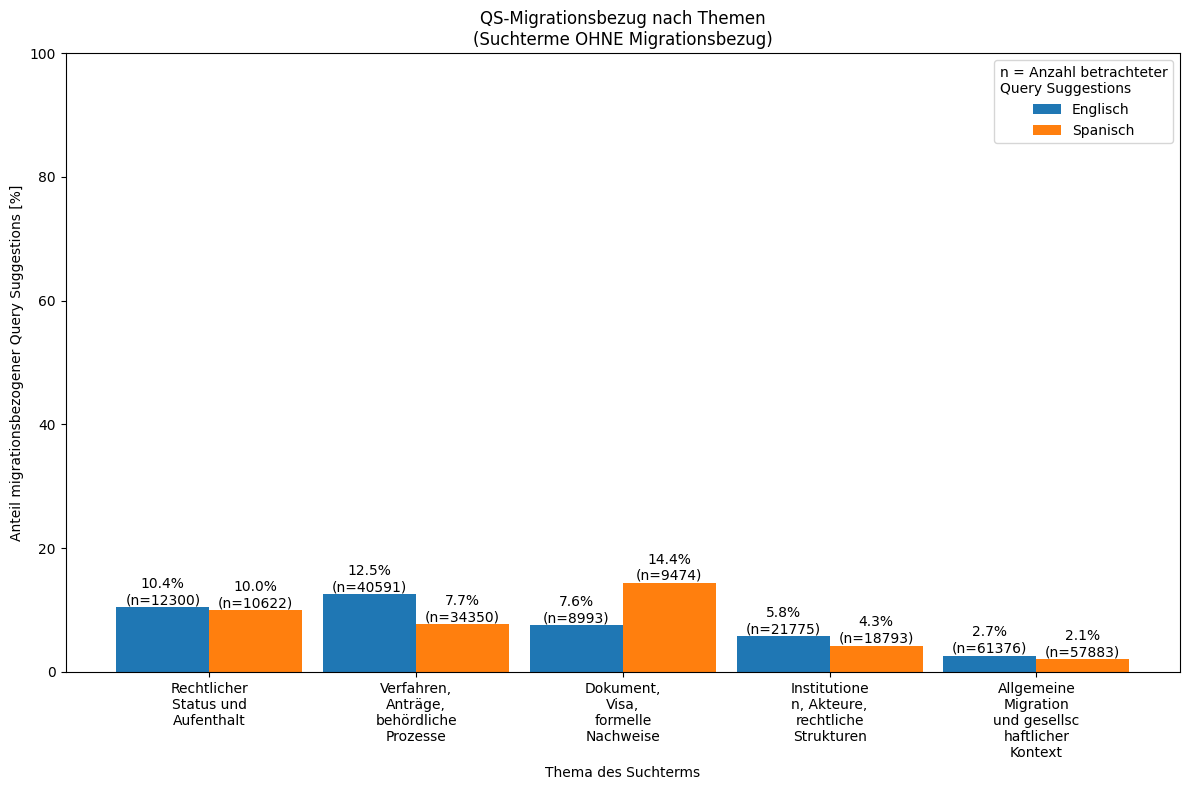

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# ------------------------------------------------------------
# Hilfsfunktion: Zeilenumbruch für lange Topics
# ------------------------------------------------------------
def wrap_text(text, width=12):
    return "\n".join(textwrap.wrap(str(text), width))

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Optional: numerisch machen
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion mit topic + topic_number
# ------------------------------------------------------------
def qs_share_by_topic(df, lang):

    qs_col = f'qs_{lang}'
    qs_mig_col = f'qs_migrationsbezug_{lang}_final'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        df[qs_col].notna() &
        df[qs_mig_col].notna() &
        df[term_mig_col].notna() &
        df['topic_number'].notna() &
        df['topic'].notna()
    ].copy()

    # MIT Migrationsbezug
    subset_with = subset[subset[term_mig_col] == 1]

    with_grouped = (
        subset_with
        .groupby(['topic_number', 'topic'])
        .agg(
            pct=(qs_mig_col, lambda x: x.mean() * 100),
            n=(qs_col, 'count')
        )
        .reset_index()
    )

    # OHNE Migrationsbezug
    subset_without = subset[subset[term_mig_col] == 0]

    without_grouped = (
        subset_without
        .groupby(['topic_number', 'topic'])
        .agg(
            pct=(qs_mig_col, lambda x: x.mean() * 100),
            n=(qs_col, 'count')
        )
        .reset_index()
    )

    return with_grouped, without_grouped

# ------------------------------------------------------------
# Englisch & Spanisch
# ------------------------------------------------------------
eng_with, eng_without = qs_share_by_topic(df, 'eng')
spa_with, spa_without = qs_share_by_topic(df, 'spa')

# ------------------------------------------------------------
# Merge + Sortierung
# ------------------------------------------------------------
def merge_lang(eng_df, spa_df):
    merged = pd.merge(
        eng_df,
        spa_df,
        on=['topic_number', 'topic'],
        how='outer',
        suffixes=('_eng', '_spa')
    ).sort_values('topic_number')

    return merged

merged_with = merge_lang(eng_with, spa_with)
merged_without = merge_lang(eng_without, spa_without)

# ------------------------------------------------------------
# Plot-Funktion
# ------------------------------------------------------------
def plot_topic_bars(merged_df, title):

    topics = merged_df['topic'].apply(lambda x: wrap_text(x, width=12))
    x = np.arange(len(topics))
    width = 0.45

    plt.figure(figsize=(12, 8))

    bars1 = plt.bar(x - width/2, merged_df['pct_eng'], width, label='Englisch')
    bars2 = plt.bar(x + width/2, merged_df['pct_spa'], width, label='Spanisch')

    plt.ylabel('Anteil migrationsbezogener Query Suggestions [%]')
    plt.xlabel('Thema des Suchterms')
    plt.ylim(0, 100)
    plt.title(title)

    plt.xticks(x, topics, rotation=0)
    plt.legend(title='n = Anzahl betrachteter\nQuery Suggestions')

    # Labels
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        if pd.notna(height):
            n = merged_df['n_eng'].iloc[i]
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{height:.1f}%\n(n={int(n)})',
                ha='center',
                va='bottom'
            )

    for i, bar in enumerate(bars2):
        height = bar.get_height()
        if pd.notna(height):
            n = merged_df['n_spa'].iloc[i]
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{height:.1f}%\n(n={int(n)})',
                ha='center',
                va='bottom'
            )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 1: MIT Migrationsbezug
# ------------------------------------------------------------
plot_topic_bars(
    merged_with,
    'QS-Migrationsbezug nach Themen\n(Suchterme MIT Migrationsbezug)'
)

# ------------------------------------------------------------
# Plot 2: OHNE Migrationsbezug
# ------------------------------------------------------------
plot_topic_bars(
    merged_without,
    'QS-Migrationsbezug nach Themen\n(Suchterme OHNE Migrationsbezug)'
)

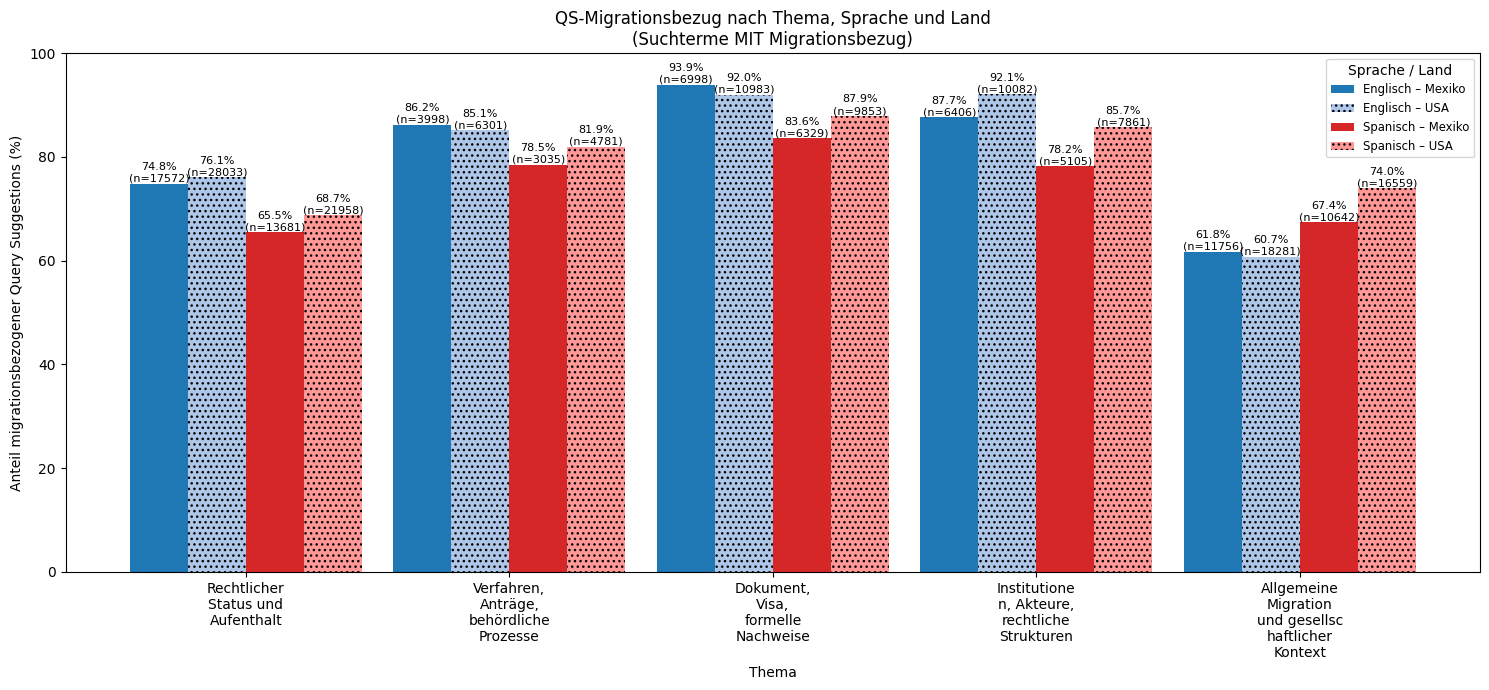

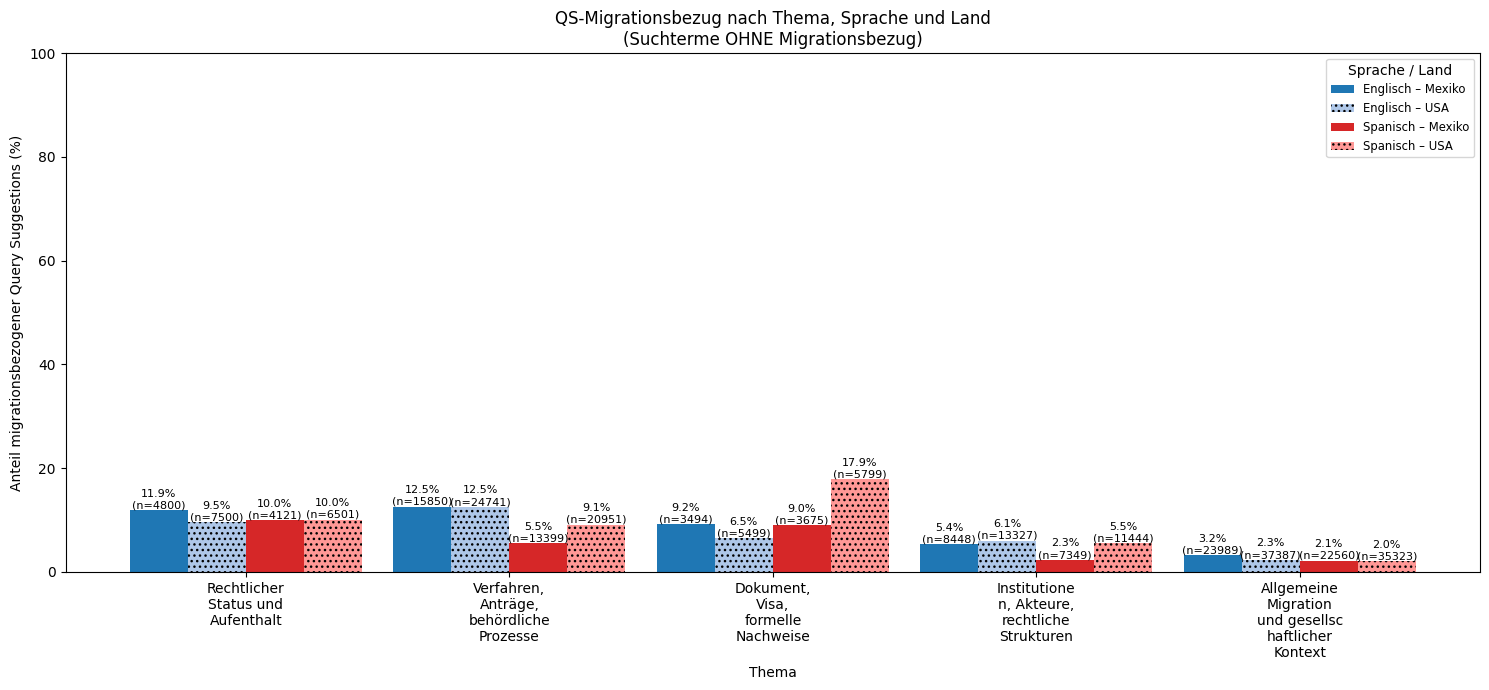

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# ------------------------------------------------------------
# Hilfsfunktion: Zeilenumbruch
# ------------------------------------------------------------
def wrap_text(text, width=12):
    return "\n".join(textwrap.wrap(str(text), width))

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

laender = ['USA', 'Mexiko']

# Numerisch absichern
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa',
    'topic_number'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion
# ------------------------------------------------------------
def build_plot_df(df, term_has_migration):

    rows = []

    for land in laender:
        df_land = df[df['land'] == land]

        # Englisch
        subset_eng = df_land[
            (df_land['qs_eng'].notna()) &
            (df_land['qs_migrationsbezug_eng_final'].notna()) &
            (df_land['migrationsbezug_eng'] == term_has_migration) &
            (df_land['topic_number'].notna()) &
            (df_land['topic'].notna())
        ]

        eng = (
            subset_eng
            .groupby(['topic_number', 'topic'])
            .agg(
                pct=('qs_migrationsbezug_eng_final', lambda x: x.mean() * 100),
                n=('qs_eng', 'count')
            )
            .reset_index()
        )
        eng['label'] = f'Englisch – {land}'

        # Spanisch
        subset_spa = df_land[
            (df_land['qs_spa'].notna()) &
            (df_land['qs_migrationsbezug_spa_final'].notna()) &
            (df_land['migrationsbezug_spa'] == term_has_migration) &
            (df_land['topic_number'].notna()) &
            (df_land['topic'].notna())
        ]

        spa = (
            subset_spa
            .groupby(['topic_number', 'topic'])
            .agg(
                pct=('qs_migrationsbezug_spa_final', lambda x: x.mean() * 100),
                n=('qs_spa', 'count')
            )
            .reset_index()
        )
        spa['label'] = f'Spanisch – {land}'

        rows.append(eng)
        rows.append(spa)

    combined = pd.concat(rows)

    # Pivot für Plot
    plot_df = combined.pivot_table(
        index=['topic_number', 'topic'],
        columns='label',
        values='pct'
    )

    count_df = combined.pivot_table(
        index=['topic_number', 'topic'],
        columns='label',
        values='n'
    )

    # Sortieren nach topic_number
    plot_df = plot_df.sort_index(level=0)
    count_df = count_df.sort_index(level=0)

    return plot_df, count_df

# ------------------------------------------------------------
# Daten
# ------------------------------------------------------------
plot_df_with, count_df_with = build_plot_df(df, 1)
plot_df_without, count_df_without = build_plot_df(df, 0)

# ------------------------------------------------------------
# Plot-Funktion
# ------------------------------------------------------------
def plot_master(plot_df, count_df, title):

    topics = plot_df.index.get_level_values('topic')
    topics_wrapped = [wrap_text(t, 12) for t in topics]

    x = np.arange(len(topics))
    width = 0.22  # breiter, weniger Abstand

    plt.figure(figsize=(15, 7))

    colors = ['#1f77b4', '#aec7e8', '#d62728', '#ff9896']
    hatches = ['', '...', '', '...']

    for i, col in enumerate(plot_df.columns):
        bars = plt.bar(
            x + (i - 1.5) * width,
            plot_df[col],
            width,
            label=col,
            color=colors[i],
            hatch=hatches[i]
        )

        # Labels mit n
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if pd.notna(height):
                n = count_df[col].iloc[j]
                plt.text(
                    bar.get_x() + bar.get_width()/2,
                    height,
                    f'{height:.1f}%\n(n={int(n)})',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    plt.ylabel('Anteil migrationsbezogener Query Suggestions [%]')
    plt.xlabel('Thema des Suchterms')
    plt.ylim(0, 100)
    plt.title(title)

    plt.xticks(x, topics_wrapped, rotation=0)
    plt.legend(title='Sprache / Land', fontsize='small')

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 1
# ------------------------------------------------------------
plot_master(
    plot_df_with,
    count_df_with,
    'QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme MIT Migrationsbezug)'
)

# ------------------------------------------------------------
# Plot 2
# ------------------------------------------------------------
plot_master(
    plot_df_without,
    count_df_without,
    'QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme OHNE Migrationsbezug)'
)

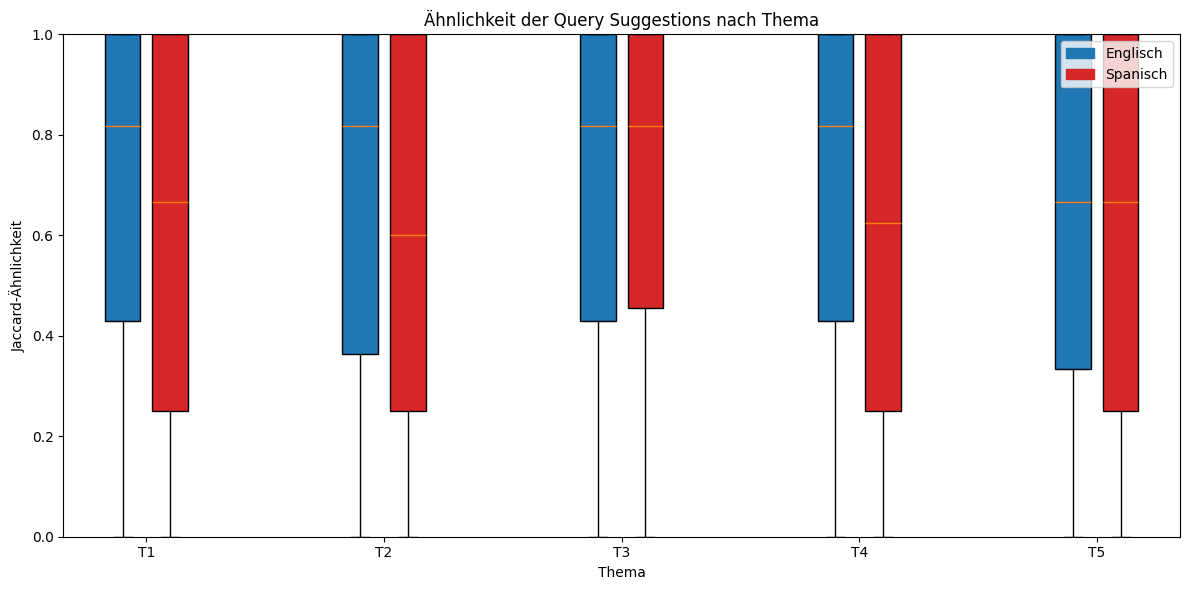

In [20]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Datengrundlage
# ------------------------------------------------------------
df = clean_df.copy()

df_en = df[
    (df['qs_eng'].notna()) &
    (df['english_term'].notna()) &
    (df['topic_number'].notna())
].copy()

df_es = df[
    (df['qs_spa'].notna()) &
    (df['spanish_term'].notna()) &
    (df['topic_number'].notna())
].copy()

# ------------------------------------------------------------
# Standort-ID
# ------------------------------------------------------------
def add_location_id(df):
    df['location_id'] = (
        df['land'].astype(str) + " | " +
        df['bundesstaat'].astype(str) + " | " +
        df['stadt'].astype(str)
    )
    return df

df_en = add_location_id(df_en)
df_es = add_location_id(df_es)

# ------------------------------------------------------------
# Jaccard
# ------------------------------------------------------------
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return np.nan
    union = set_a | set_b
    if len(union) == 0:
        return np.nan
    return len(set_a & set_b) / len(union)

# ------------------------------------------------------------
# Funktion: Similarity pro Thema (mit Standort!)
# ------------------------------------------------------------
def compute_similarity_per_topic(df, term_col, qs_col):

    # Sets pro Term + Standort
    term_loc_sets = (
        df.groupby(['topic_number', term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    topic_results = {}

    for topic, group in term_loc_sets.groupby('topic_number'):

        sims = []

        # pro Term vergleichen (Standorte untereinander)
        for term, sub in group.groupby(term_col):
            loc_sets = list(sub['qs_set'])

            if len(loc_sets) < 2:
                continue

            for set1, set2 in combinations(loc_sets, 2):
                sims.append(jaccard_similarity(set1, set2))

        if sims:
            topic_results[topic] = sims

    return topic_results

# ------------------------------------------------------------
# Berechnung
# ------------------------------------------------------------
eng_dict = compute_similarity_per_topic(df_en, 'english_term', 'qs_eng')
spa_dict = compute_similarity_per_topic(df_es, 'spanish_term', 'qs_spa')

topics = sorted(set(eng_dict.keys()) | set(spa_dict.keys()))

# ------------------------------------------------------------
# Boxplot vorbereiten
# ------------------------------------------------------------
plot_data = []
positions = []
labels = []

pos = 1

for topic in topics:

    # Englisch
    plot_data.append(pd.Series(eng_dict.get(topic, [])).dropna())
    positions.append(pos)

    # Spanisch
    plot_data.append(pd.Series(spa_dict.get(topic, [])).dropna())
    positions.append(pos + 0.4)

    labels.append(f'T{topic}')
    pos += 2

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

bp = plt.boxplot(plot_data, positions=positions, widths=0.3, patch_artist=True)

# Farben
colors = ['#1f77b4', '#d62728'] * len(topics)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# X-Ticks
tick_positions = [i + 0.2 for i in range(1, len(topics)*2, 2)]
plt.xticks(tick_positions, labels)

plt.ylabel('Jaccard-Ähnlichkeit')
plt.xlabel('Thema')
plt.title('Ähnlichkeit der Query Suggestions nach Thema')

# Legende
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='#1f77b4', label='Englisch'),
    mpatches.Patch(color='#d62728', label='Spanisch')
]
plt.legend(handles=legend_patches)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [21]:
summary_rows = []

for topic in topics:
    eng_vals = pd.Series(eng_dict.get(topic, [])).dropna()
    spa_vals = pd.Series(spa_dict.get(topic, [])).dropna()

    summary_rows.append({
        'Thema': topic,
        'Englisch Mean': eng_vals.mean(),
        'Englisch Median': eng_vals.median(),
        'Spanisch Mean': spa_vals.mean(),
        'Spanisch Median': spa_vals.median()
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df.round(3))

   Thema  Englisch Mean  Englisch Median  Spanisch Mean  Spanisch Median
0      1          0.713            0.818          0.624            0.667
1      2          0.706            0.818          0.599            0.600
2      3          0.688            0.818          0.734            0.818
3      4          0.689            0.818          0.599            0.625
4      5          0.618            0.667          0.624            0.667


In [22]:
# ------------------------------------------------------------
# Funktion: Setgrößen pro Thema berechnen
# ------------------------------------------------------------
def compute_set_sizes(df, term_col, qs_col, lang_label):

    term_loc_sets = (
        df.groupby(['topic_number', term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    # Setgröße berechnen
    term_loc_sets['set_size'] = term_loc_sets['qs_set'].apply(len)

    # Describe pro Thema
    summary = (
        term_loc_sets
        .groupby('topic_number')['set_size']
        .describe()
    )

    # Mean separat (oft übersichtlicher)
    means = (
        term_loc_sets
        .groupby('topic_number')['set_size']
        .mean()
    )

    print(f"\n=== {lang_label} – Setgrößen nach Thema ===")
    print(summary)

    print(f"\n=== {lang_label} – mittlere Setgröße nach Thema ===")
    print(means)

    return term_loc_sets

# ------------------------------------------------------------
# Anwendung
# ------------------------------------------------------------
eng_sets = compute_set_sizes(df_en, 'english_term', 'qs_eng', 'Englisch')
spa_sets = compute_set_sizes(df_es, 'spanish_term', 'qs_spa', 'Spanisch')


=== Englisch – Setgrößen nach Thema ===
               count      mean       std  min   25%   50%   75%   max
topic_number                                                         
1             6187.0  9.359140  2.075911  1.0  10.0  10.0  10.0  10.0
2             5166.0  9.850949  0.597385  5.0  10.0  10.0  10.0  10.0
3             2704.0  9.975592  0.154342  9.0  10.0  10.0  10.0  10.0
4             3935.0  9.723761  1.252423  1.0  10.0  10.0  10.0  10.0
5             9100.0  9.955275  0.295550  7.0  10.0  10.0  10.0  10.0

=== Englisch – mittlere Setgröße nach Thema ===
topic_number
1    9.359140
2    9.850949
3    9.975592
4    9.723761
5    9.955275
Name: set_size, dtype: float64

=== Spanisch – Setgrößen nach Thema ===
               count      mean       std  min   25%   50%   75%   max
topic_number                                                         
1             6232.0  7.423139  3.417909  1.0   4.0  10.0  10.0  10.0
2             5166.0  8.162214  2.736228  1.0   6.0  10